import of lib


In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer 
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn .neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score , classification_report , roc_auc_score , roc_curve
import matplotlib.pyplot as plt 
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import StandardScaler

load data 

In [2]:
df = pd.read_csv("star_classification.csv")

Read and explore the data 


In [3]:
print(df.columns)

Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='object')


In [4]:
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [6]:
df.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


on remarque qu'on a des valeur 9999 qui ne reflaire pas true values 


In [7]:
#df.replace(-9999, np.nan, inplace=True)

In [8]:
print(df.isna().sum())

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64


on garde pas tous les colonnes , on rage seulement les colonnes qui fournis des infos intresting 

In [9]:
columns_to_drop = [
    'obj_ID',
    'run_ID',
    'rerun_ID',
    'field_ID',
    'spec_obj_ID',
    'plate',
    'MJD',
    'fiber_ID',
    'cam_col'
]
df.drop(columns=columns_to_drop, axis=1, inplace=True)

In [10]:
df.dropna(inplace=True)

In [11]:
df.shape

(100000, 9)

In [12]:
df['class'].unique()

array(['GALAXY', 'QSO', 'STAR'], dtype=object)

## Équilibrage des données par Undersampling

Le dataset initial est déséquilibré (on a 59% galaxies, 22% étoiles, 19% quasars).  
Pour éviter un biais de modèle vers la classe majoritaire,on aappliqué **l'undersampling** pour uniformiser le nombre d'exemples par classe.

**Méthode choisie** :  
- Réduire aléatoirement les classes majoritaires pour égaliser leur taille avec celle de la classe minoritaire.

In [13]:
# Séparer les classes
galaxy = df[df['class'] == 'GALAXY']
star = df[df['class'] == 'STAR']
qso = df[df['class'] == 'QSO']

In [14]:
# Effectuer le undersampling sur les classes GALAXY et STAR pour qu'elles aient le même nombre d'exemples que QSO
n_qso = len(qso)

In [15]:
from sklearn.utils import resample

# Sous-échantillonner
galaxy_resampled = resample(galaxy, replace=False, n_samples=n_qso, random_state=42)
star_resampled = resample(star, replace=False, n_samples=n_qso, random_state=42)

# Fusionner les données sous-échantillonnées avec QSO
df_resampled = pd.concat([galaxy_resampled, star_resampled, qso])

# Mélanger les données (facultatif)
df_resampled = df_resampled.sample(frac=1, random_state=42).reset_index(drop=True)


In [16]:
df_resampled['class'].value_counts()

class
QSO       18961
GALAXY    18961
STAR      18961
Name: count, dtype: int64

In [17]:
df.sort_values("class")

,alpha,delta,u,g,r,i,z,class,redshift
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,GALAXY,0.634794
58230,142.047959,51.231393,21.97755,21.53166,21.32114,20.86099,20.36108,GALAXY,0.931503
58228,140.841355,50.692416,23.41943,22.03784,21.14735,20.79810,20.37284,GALAXY,0.255631
58227,223.984760,-1.841606,22.18194,21.53138,20.52969,19.49590,18.90042,GALAXY,0.509081
58226,216.754539,-1.946554,25.55715,20.90226,19.11438,18.38413,17.95209,GALAXY,0.417001
...,...,...,...,...,...,...,...,...,...
46329,251.580659,38.559354,23.41423,21.04343,19.71153,19.26199,19.02872,STAR,-0.000387
46330,237.215497,25.986546,17.54356,16.42303,15.91468,15.71449,15.61154,STAR,-0.000482
46331,109.885032,0.048816,22.43742,19.55231,18.46435,18.01848,17.74893,STAR,0.000177
75082,158.030632,-1.411047,21.96090,20.85199,20.60211,20.44812,20.24777,STAR,0.000930


In [18]:
df['class'].value_counts()

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

**Résultats**

<Axes: xlabel='class', ylabel='count'>

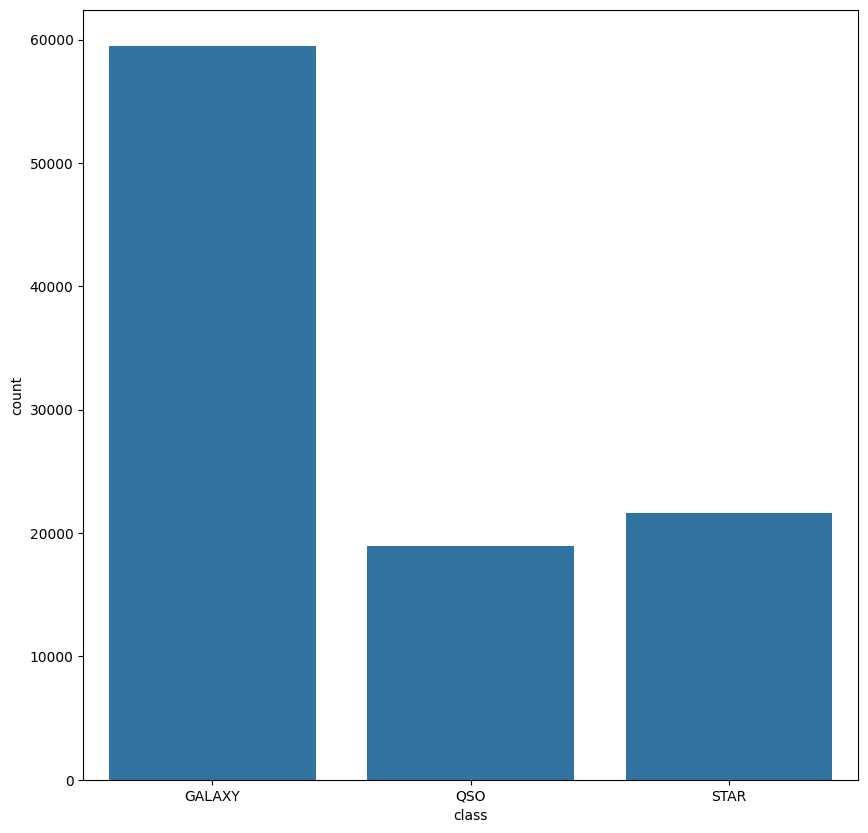

In [19]:
plt.figure(figsize=(10,10))
sns.countplot(data=df,x="class")

<Axes: xlabel='class', ylabel='count'>

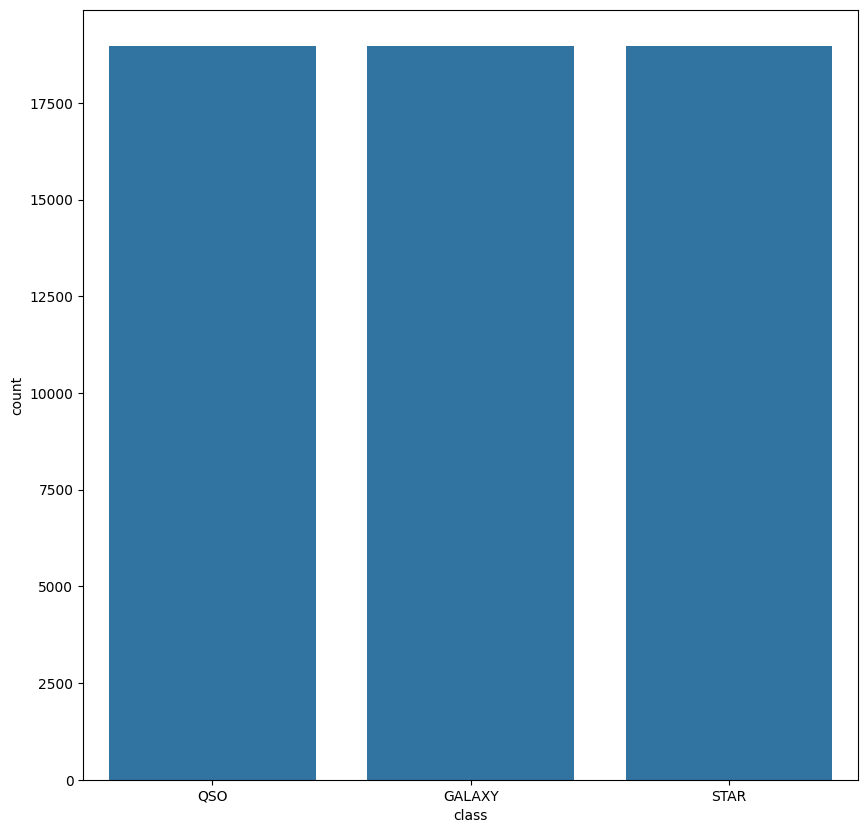

In [20]:
plt.figure(figsize=(10,10))
sns.countplot(data=df_resampled,x="class")

([<matplotlib.patches.Wedge at 0x2428c719eb0>,
 [Text(-0.3216272173789337, 1.051929623616088, 'GALAXY'),
  Text(-0.3239728375169962, -1.0512095892595283, 'STAR'),
  Text(0.9105456051052268, -0.6171763937672573, 'QSO')],
 [Text(-0.17543302766123656, 0.5737797946996842, '59%'),
  Text(-0.17671245682745243, -0.5733870486870154, '22%'),
  Text(0.49666123914830546, -0.3366416693275948, '19%')])

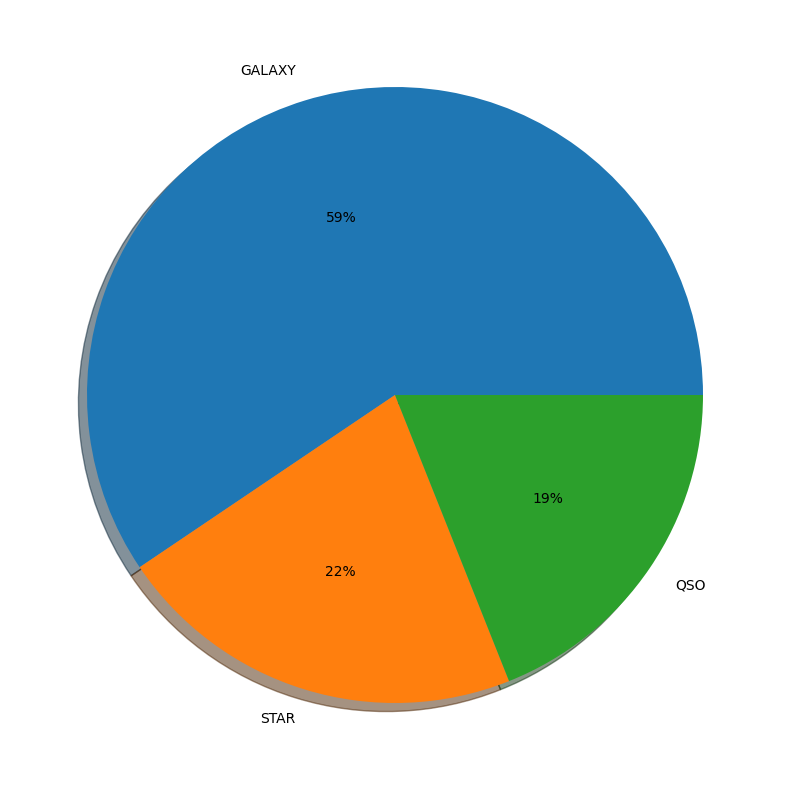

In [21]:
plt.figure(figsize=(10,10))
plt.pie(x=df['class'].value_counts(),labels=["GALAXY","STAR","QSO"],autopct="%1.f%%",shadow=True)

([<matplotlib.patches.Wedge at 0x2428c781c10>,
 [Text(0.5499999722395388, 0.9526279601903919, 'GALAXY'),
  Text(-1.0999999999999959, -9.616505800409723e-08, 'STAR'),
  Text(0.5500003659264656, -0.9526277328950455, 'QSO')],
 [Text(0.29999998485793017, 0.5196152510129409, '33%'),
  Text(-0.5999999999999978, -5.2453668002234845e-08, '33%'),
  Text(0.3000001995962539, -0.5196151270336611, '33%')])

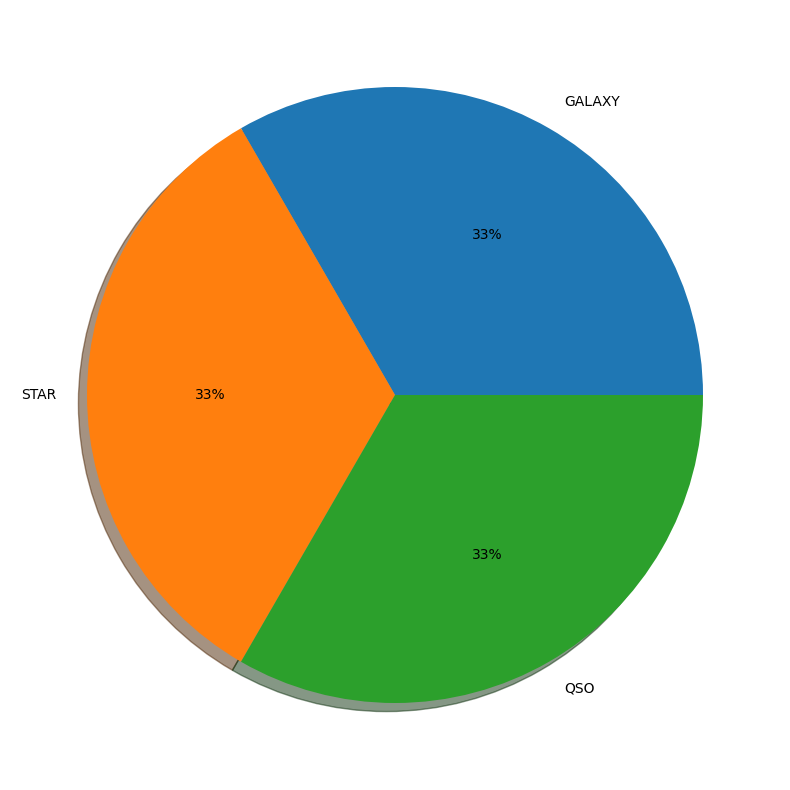

In [22]:
plt.figure(figsize=(10,10))
plt.pie(x=df_resampled['class'].value_counts(),labels=["GALAXY","STAR","QSO"],autopct="%1.f%%",shadow=True)

preprocessing & correlation matrix & feature selection

In [23]:
from sklearn.calibration import LabelEncoder
encoder=LabelEncoder()
df_resampled['class']=encoder.fit_transform(df_resampled['class'])
for i, class_name in enumerate(encoder.classes_):
    print(f"Classe {i} → {class_name}")


Classe 0 → GALAXY
Classe 1 → QSO
Classe 2 → STAR


In [24]:
def plot(column,df):
    for i in range(3):
        sns.kdeplot(data=df[df["class"] == i][column], label = encoder.inverse_transform([i]), fill = True)
    sns.kdeplot(data=df[column],label = ["All"], fill = True)
    plt.legend();
    
def log_plot(column):
    for i in range(3):
        sns.kdeplot(data=np.log(df[df["class"] == i][column]), label = encoder.inverse_transform([i]), fill = True)
    sns.kdeplot(data=np.log(df[column]),label = ["All"], fill = True)
    plt.legend()

Text(0.5, 1.0, ' stellar correlation matrix')

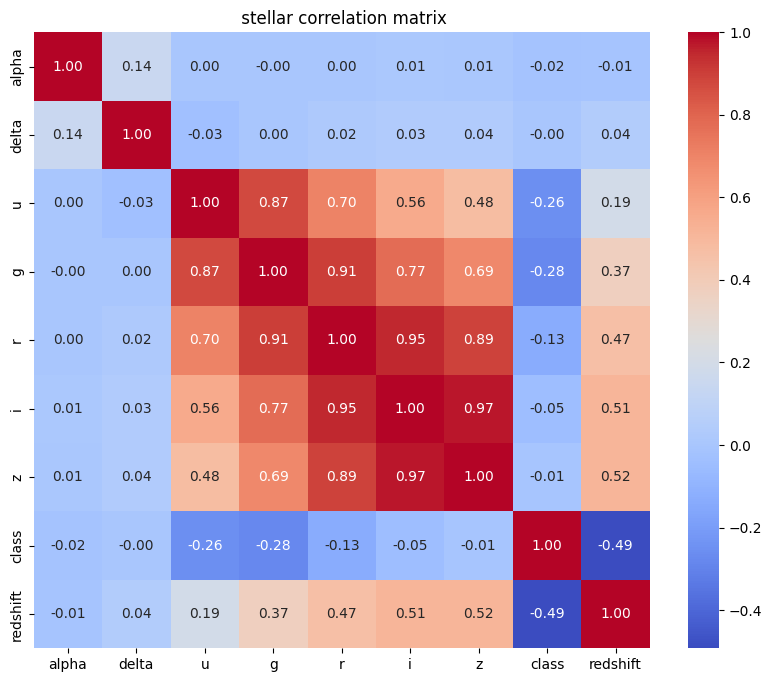

In [25]:
corr_matt=df_resampled.corr(method="spearman")
plt.figure(figsize=(10,8))
sns.heatmap(corr_matt,annot=True,fmt="0.2f",cmap="coolwarm",square=True)
plt.title(" stellar correlation matrix")

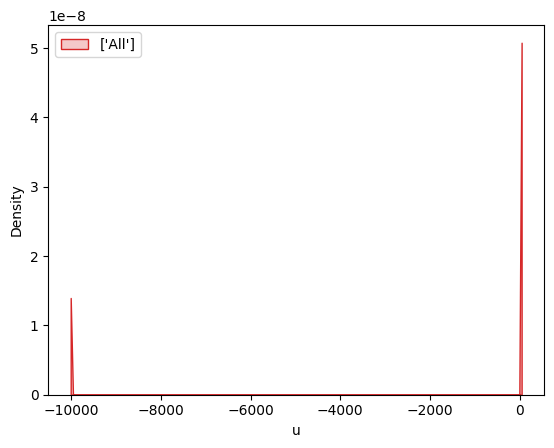

In [26]:
plot('u',df)

In [27]:
#plot('g')

In [28]:
import pandas as pd
import numpy as np

def remove_outliers_iqr(df, cols=None, visualize=False):
    """
    Returns a copy of df with outliers removed using IQR method.
    Optionally specify columns; if none, all numeric columns are used.
    """
    df_clean = df.copy()
    original_shape = df.shape

    if cols is None:
        cols = df.select_dtypes(include='number').columns

    for col in cols:
        q1 = df_clean[col].quantile(0.25)
        q3 = df_clean[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

    removed = original_shape[0] - df_clean.shape[0]
    print(f"Outliers removed: {removed} rows")

    return df_clean


In [29]:
# Remove outliers from the whole DataFrame (safe version)
clean_star = remove_outliers_iqr(df_resampled)

# Remove outliers only from specific columns
#clean_star = remove_outliers_iqr(star, cols=['u', 'g', 'r', 'i', 'z'])

# View how many rows were removed
print(f"After cleaning: {clean_star.shape}")


Outliers removed: 1962 rows
After cleaning: (54921, 9)


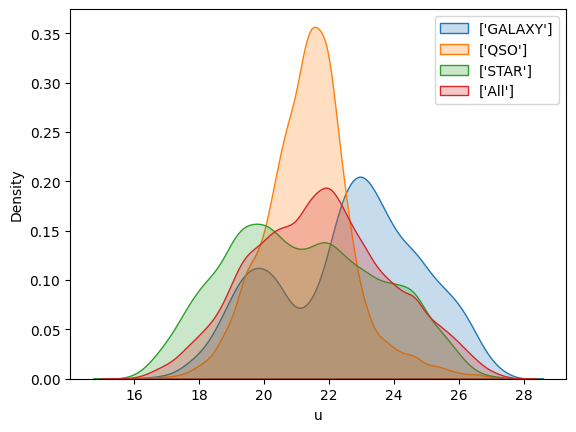

In [30]:
plot('u',clean_star)

In [31]:
x=clean_star.drop("class",axis=1)
y=clean_star['class']


In [32]:
scaler=StandardScaler()
x_scaler=scaler.fit_transform(x)

## Train/Test split

In [33]:
x_train,x_test,y_train,y_test=train_test_split(x_scaler,y,test_size=0.3,random_state=42)

In [34]:
x_train.shape


(38444, 8)

In [35]:
y_train.shape

(38444,)

In [36]:
x_test.shape

(16477, 8)

In [37]:
num_classes = len(np.unique(y))
print(num_classes)
print(y)

3
0        1
1        0
2        0
3        1
4        2
        ..
56878    1
56879    1
56880    0
56881    0
56882    1
Name: class, Length: 54921, dtype: int64


## Algorithme K-Nearest Neighbors (KNN)

###  **Principe**  
KNN est un algorithme simple de **classification** ou **régression** qui prédit une cible en fonction des **K exemples les plus proches** dans les données d'entraînement.

###  **Fonctionnement**  
1. **Choix de K** : Sélectionner un nombre impair (ex: 3, 5) pour éviter les égalités.  
2. **Calcul des distances** : Mesurer la distance (euclidienne, Manhattan...) entre la nouvelle donnée et toutes les autres.  
3. **Prédiction** :  
   - **Classification** : Vote majoritaire parmi les K voisins.  
   - **Régression** : Moyenne des valeurs des voisins.  

###  **Avantages**  
- Simple à comprendre et implémenter.  
- Aucun entraînement explicite (juste une mémoire des données).  

###  **Limites**  
- Coûteux en calcul pour grands datasets (`O(n)` par prédiction).  
- Sensible au bruit et aux features non pertinentes.   

In [38]:
import time
K = []
training = []
test = []
scores = {}
start_time=time.time()
for k in range(1, 21,2):
    clf = KNeighborsClassifier(n_neighbors = k)
    clf.fit(x_train, y_train)

    training_score = clf.score(x_train, y_train)
    test_score = clf.score(x_test, y_test)
    K.append(k)

    training.append(training_score)
    test.append(test_score)
    scores[k] = [training_score, test_score]
knn_time=time.time()-start_time

evaluate the model 

In [39]:
for keys, values in scores.items():
    print(keys, ':', values)


1 : [1.0, 0.9277781149481095]
3 : [0.9583029861616897, 0.9366389512654003]
5 : [0.9483924669649361, 0.9330582023426595]
7 : [0.943138070960358, 0.9303271226558233]
9 : [0.9387420663822703, 0.9285064028645992]
11 : [0.9358287379044844, 0.9280208775869394]
13 : [0.9327853501196546, 0.9270498270316199]
15 : [0.9306263656227239, 0.9252291072403958]
17 : [0.9287535116012902, 0.9241973660253687]
19 : [0.926932681302674, 0.9229228621715118]


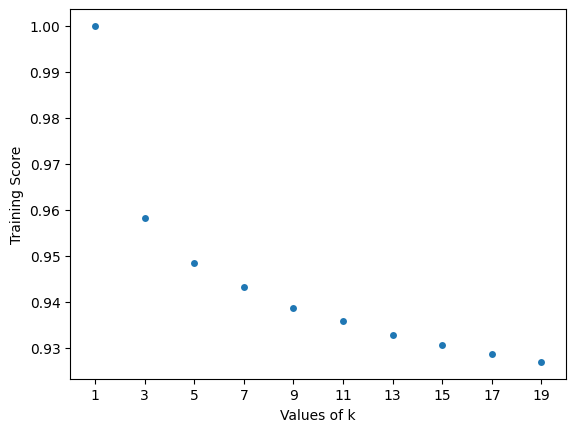

In [40]:
ax = sns.stripplot(x=K, y=training)  # Use x and y as keyword arguments
ax.set(xlabel='Values of k', ylabel='Training Score')
plt.show()


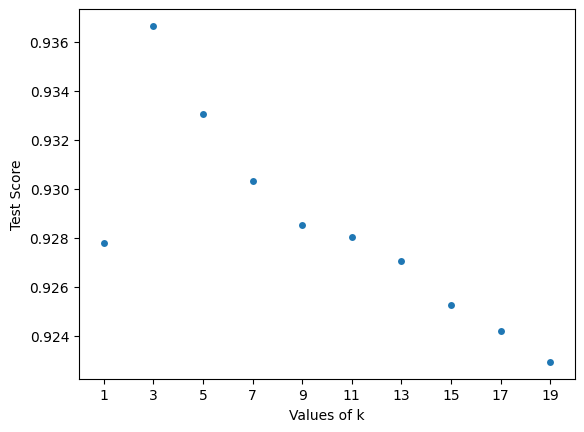

In [41]:
ax = sns.stripplot(x=K, y=test)  # Use x and y as keyword arguments
ax.set(xlabel='Values of k', ylabel='Test Score')
plt.show()


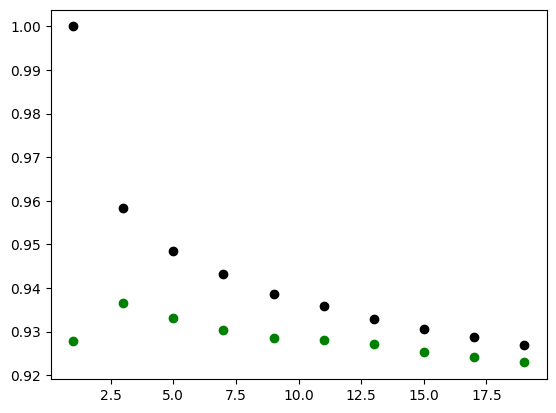

In [42]:
plt.scatter(K, training, color='k')
plt.scatter(K, test, color='g')
plt.show()


## Algorithme Decision Tree (Arbre de Décision)

### **Principe**  
Un arbre de décision est un modèle supervisé qui **segmente récursivement** les données en sous-ensembles homogènes, basé sur des règles "SI...ALORS". Il fonctionne pour la **classification** et la **régression**.

### **Fonctionnement**  
1. **Construction** :  
   - Divise les données en branches selon le **meilleur critère** (Gini, Entropie, MSE).  
   - Répète jusqu'à atteindre une profondeur max ou une pureté parfaite.  
2. **Prédiction** :  
   - Parcourt l'arbre de la **racine** jusqu'à une **feuille** (classe/valeur finale).  
### **Paramètres Clés**  
- `max_depth` : Profondeur maximale (évite le sur-apprentissage).  
- `min_samples_split` : Nombre minimal d'échantillons pour diviser un nœud.  
- `criterion` : Critère de division (`gini`, `entropy`, ou `mse`). 
### **Avantages**  
-  **Interprétable** : Visualisable avec `plot_tree`.  
-  **Peu de prétraitement** : Gère les données non linéaires et catégorielles.  
-  **Rapide** à l'entraînement et à la prédiction.  

###  **Limites**  
- **Sensible au bruit** : Peut créer des règles trop spécifiques (sur-apprentissage).  
- **Instable** : Petits changements ⇒ arbre très différent (utiliser `random_state`).


In [ ]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 2]
}



In [63]:
start_time2 = time.time()
dt = DecisionTreeClassifier(random_state=42)
best_model_dt = GridSearchCV(estimator=dt,
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1,
                           scoring='accuracy',
                           verbose=1)

best_model_dt.fit(x_train, y_train)
dt_time = time.time() - start_time2


Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [45]:
print("Best Parameters:", best_model_dt.best_params_)
best_dt = best_model_dt.best_estimator_

# Évaluer sur le test set
y_pred_dt = best_dt.predict(x_test)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_dt))


Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      5651
           1       0.97      0.93      0.95      5142
           2       1.00      1.00      1.00      5684

    accuracy                           0.97     16477
   macro avg       0.97      0.97      0.97     16477
weighted avg       0.97      0.97      0.97     16477



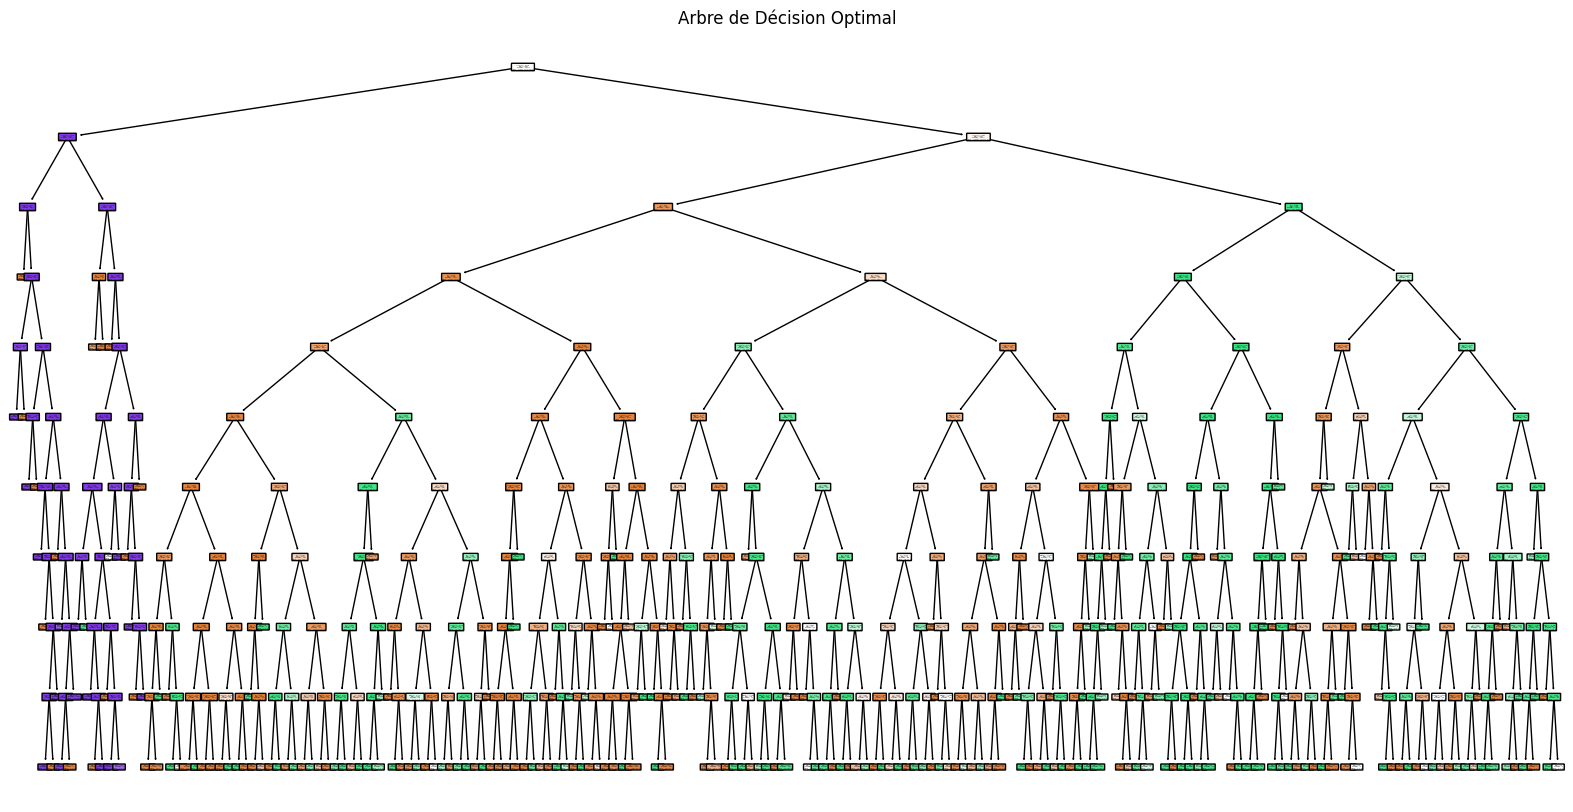

In [46]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
feature_names = df.columns[df.columns != 'class'].tolist()

# Afficher l'arbre
plt.figure(figsize=(20, 10))  # Taille de la figure
plot_tree(
    best_dt,                   # Ton meilleur modèle
    filled=True,              # Colorer les classes
    feature_names=feature_names,  # Noms des features
    class_names=best_dt.classes_.astype(str),  # Noms des classes
    rounded=True              # Coins arrondis
)
plt.title("Arbre de Décision Optimal")
plt.show()


##  Métriques d'Évaluation pour la Classification
- **Matrice de Confusion** : Visualisation des Vrais Positifs, Vrais Négatifs, Faux Positifs, Faux Négatifs
à de cette matrice on peut calculer:
1. **Accuracy** (Exactitude)  
   ```math
   \frac{\text{Vrais Positifs} + \text{Vrais Négatifs}}{\text{Total}}
   ```
   - *Avantage* : Simple à interpréter  
   - *Limite* : Trompeuse pour les classes déséquilibrées

2. **Precision** (Précision)  
   ```math
   \frac{\text{Vrais Positifs}}{\text{Vrais Positifs} + \text{Faux Positifs}}
   ```
   - *Utile* : Quand les faux positifs sont coûteux

3. **Recall** (Rappel/Sensibilité)  
   ```math
   \frac{\text{Vrais Positifs}}{\text{Vrais Positifs} + \text{Faux Négatifs}}
   ```
   - *Utile* : Quand les faux négatifs sont critiques

4. **F1-Score**  
   ```math
   2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
   ```
   - *Idéal* : Équilibre entre précision et rappel

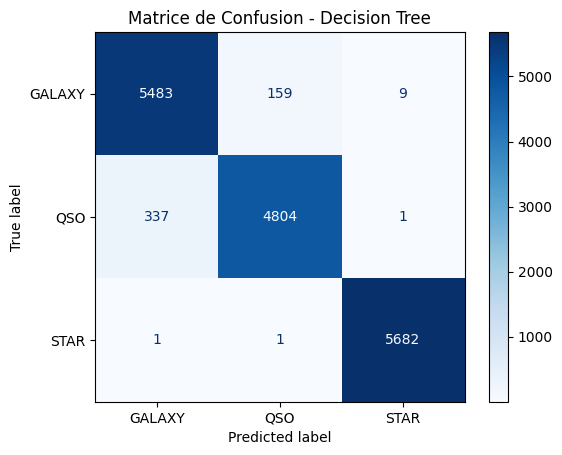

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
class_names = encoder.inverse_transform([0, 1, 2])  
# 1. Calculer les prédictions du modèle
y_pred_dt = best_model_dt.predict(x_test)  # dt_model = votre Decision Tree entraîné

# 2. Générer la matrice de confusion
cm = confusion_matrix(y_test, y_pred_dt)

# 3. Visualisation améliorée
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')  # 'd' pour afficher des entiers
plt.title("Matrice de Confusion - Decision Tree")
plt.show()

In [48]:
report = classification_report(y_test, y_pred_dt, target_names=class_names)
print("Classification Report :\n", report)

Classification Report :
               precision    recall  f1-score   support

      GALAXY       0.94      0.97      0.96      5651
         QSO       0.97      0.93      0.95      5142
        STAR       1.00      1.00      1.00      5684

    accuracy                           0.97     16477
   macro avg       0.97      0.97      0.97     16477
weighted avg       0.97      0.97      0.97     16477



## Feedforward Neural Network (Réseau de Neurones Feedforward)

### **Définition**
Un **Feedforward Neural Network (FNN)** est un type de réseau de neurones artificiels où les connexions entre les neurones ne forment pas de cycle. Les informations circulent uniquement dans un sens : de la couche d'entrée vers la couche de sortie, à travers des couches cachées.

### **Architecture**
1. **Couche d'entrée** : Reçoit les données brutes (nombre de neurones = nombre de features)
2. **Couches cachées** : Effectuent des transformations non-linéaires (1 à N couches)
3. **Couche de sortie** : Donne les prédictions finales
### **Fonctionnement**
1. **Propagation avant** :
   - Chaque neurone calcule : `sortie = activation(w * entrée + b)`
   - Fonctions d'activation courantes : ReLU, sigmoïde, tanh
2. **Apprentissage** :
   - Rétropropagation du gradient pour ajuster les poids (w) et biais (b)
   - Minimisation de la fonction de perte (ex: cross-entropy, MSE)
###  **Avantages**
-  Puissance d'approximation universelle (peut modéliser toute fonction continue)
-  Capacité à apprendre des caractéristiques complexes
-  Flexible (nombre variable de couches/neurones)

###  **Limites**
-  Requiert beaucoup de données
-  Sensible aux hyperparamètres (taux d'apprentissage, etc.)
-  Peut facilement sur-apprendre (overfitting)

In [49]:
import tensorflow as tf
from tensorflow.keras import models, layers, regularizers

# Paramètres optimisés
DROPOUT_RATE = 0.3
L2_REG = 0.001
EPOCHS = 15  # À ajuster avec EarlyStopping

model_rnn = models.Sequential([
    # Couche d'entrée avec régularisation L2
    layers.Dense(64, activation='relu', 
                kernel_regularizer=regularizers.l2(L2_REG),
                input_shape=(x_train.shape[1],)),
    
    # Dropout pour réduire le sur-apprentissage
    layers.Dropout(DROPOUT_RATE),
    
    # Couche cachée avec initialisation He (optimale pour ReLU)
    layers.Dense(32, activation='relu',
                kernel_initializer='he_normal',
                kernel_regularizer=regularizers.l2(L2_REG)),
    
    layers.Dropout(DROPOUT_RATE),
    
    # Couche supplémentaire simplifiée
    layers.Dense(16, activation='relu'),
    
    # Couche de sortie
    layers.Dense(num_classes, activation='softmax')
])

# Ajout d'EarlyStopping et réduction du learning rate
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True),
    
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3)
]

# Compilation avec un learning rate plus bas
model_rnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

C:\Users\BIG BOX\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
start_time3=time.time()
history = model_rnn.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1)
rnn_time=time.time()-start_time3

Epoch 1/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6061 - loss: 0.9157 - val_accuracy: 0.8709 - val_loss: 0.4187 - learning_rate: 5.0000e-04
Epoch 2/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8613 - loss: 0.4393 - val_accuracy: 0.9032 - val_loss: 0.3227 - learning_rate: 5.0000e-04
Epoch 3/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8939 - loss: 0.3578 - val_accuracy: 0.9346 - val_loss: 0.2629 - learning_rate: 5.0000e-04
Epoch 4/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9199 - loss: 0.2985 - val_accuracy: 0.9437 - val_loss: 0.2273 - learning_rate: 5.0000e-04
Epoch 5/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9320 - loss: 0.2623 - val_accuracy: 0.9475 - val_loss: 0.2100 - learning_rate: 5.0000e-04
Epoch 6/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9365 - loss: 0.2434 - val_accuracy: 0.9506 - val_loss: 0.1948 - learning_rate: 5.0000e-04
Epoch 7/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy

In [51]:
loss, accuracy = model_rnn.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

515/515 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9633 - loss: 0.1457
Test Accuracy: 96.19%


515/515 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
Accuracy: 0.9619469563634157
Precision: 0.962038095563118
Recall: 0.9619469563634157
F1-Score: 0.9618050735020647


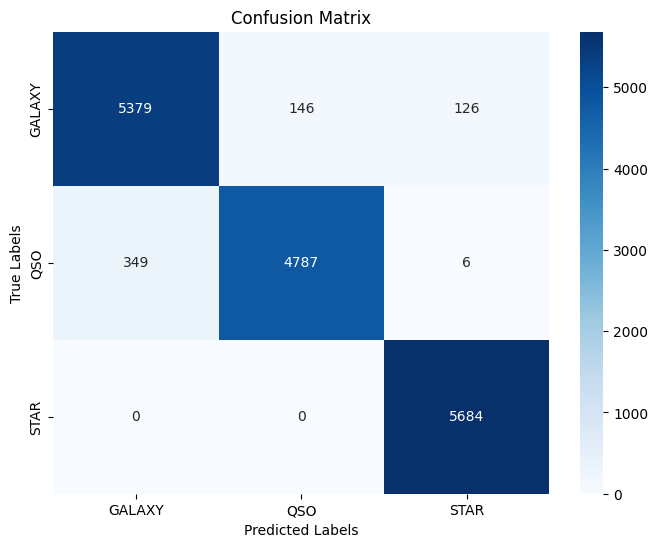

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Make predictions
y_pred = model_rnn.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # For multi-class problems

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes, average='weighted')
recall = recall_score(y_test, y_pred_classes, average='weighted')
f1 = f1_score(y_test, y_pred_classes, average='weighted')
cm = confusion_matrix(y_test, y_pred_classes)

# Print metrics
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.title('Confusion Matrix')
plt.show()


In [53]:
from sklearn.metrics import classification_report
import pandas as pd

# y_true : vraies étiquettes
# y_pred : prédictions du modèle

# Générer le rapport de classification sous forme de dictionnaire
report = classification_report(y_test, y_pred_classes, target_names=['GALAXY', 'QSO', 'STAR'], output_dict=True)

# Convertir en DataFrame
metrics_df = pd.DataFrame(report).transpose()

# Afficher le tableau
print(metrics_df)


              precision    recall  f1-score       support
GALAXY         0.939071  0.951867  0.945426   5651.000000
QSO            0.970403  0.930961  0.950273   5142.000000
STAR           0.977304  1.000000  0.988522   5684.000000
accuracy       0.961947  0.961947  0.961947      0.961947
macro avg      0.962260  0.960943  0.961407  16477.000000
weighted avg   0.962038  0.961947  0.961805  16477.000000


### **Training vs Validation Loss**
1. **Trainig loss**:Mesure l'erreur pendant l'entraînement. Baisse normalement avec les epochs.
2. **Validatio loss**:Évalue la généralisation sur des données invisibles.


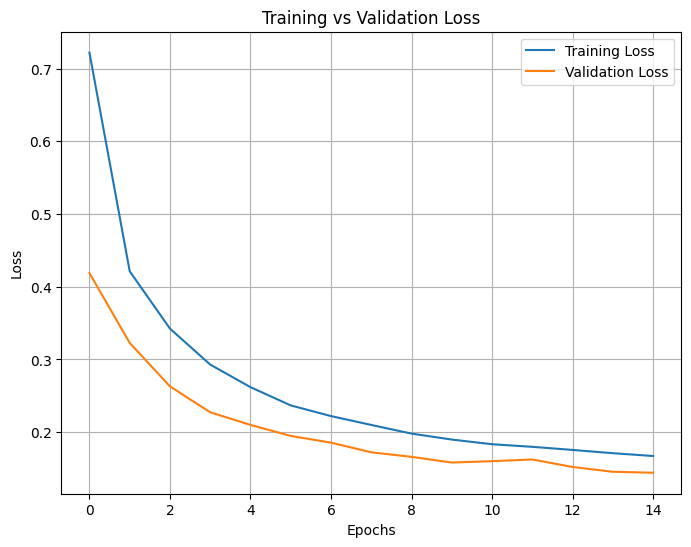

In [54]:
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

La courbe montre une descente initiale synchronisée (epochs 0-4), puis une stabilisation avec un écart modéré entre training loss (~0.2) et validation loss (~0.3). L'écart constant mais limité indique une bonne généralisation, bien que le plateau à partir de l'epoch 10 suggère que le modèle a atteint ses limites avec l'architecture actuelle. La persistance d'une validation loss à 0.3 peut signaler soit un bruit résiduel dans les données, soit le besoin d'optimisations supplémentaires (comme l'ajustement du learning rate ou l'enrichissement des features). Cette tendance est caractéristique d'un modèle bien régularisé mais arrivé à saturation.

## Courbe ROC (Receiver Operating Characteristic)

### **Définition**
Graphique évaluant les performances d'un modèle de classification binaire en comparant :
- **Axe X** : Taux de Faux Positifs (`FPR = FP / (FP + TN)`)  
- **Axe Y** : Taux de Vrais Positifs (`TPR = Recall = TP / (TP + FN)`)

###  **Interprétation**
- **Courbe proche du coin  gauche** = Meilleure performance  
- **Diagonale** = Performance aléatoire (AUC = 0.5)  
- **AUC** (Aire Sous la Courbe) : 
  - 0.9-1.0 = Excellent  
  - 0.8-0.9 = Bon  
  - <0.7 = Médiocre


515/515 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


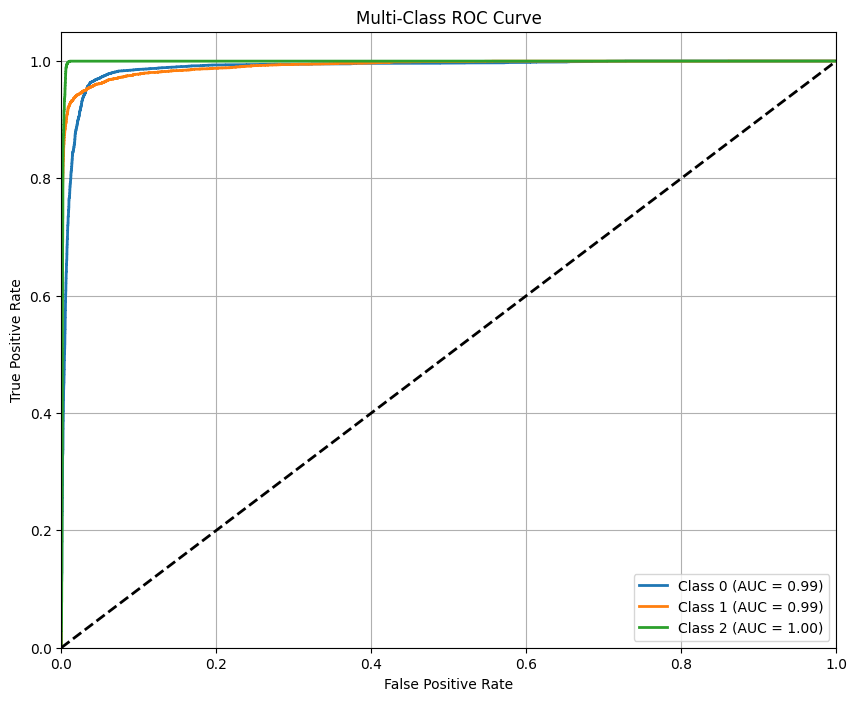

In [55]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Suppose you have these:
# y_test → your true labels (example: [0, 1, 2, 1, 0, 2, ...])
# y_pred_prob → model predicted probabilities for each class (not the predicted classes)

# Example: if you have 3 classes: galaxy (0), star (1), quasar (2)
n_classes = len(np.unique(y_test))

# Step 1: Binarize the labels
y_test_binarized = label_binarize(y_test, classes=list(range(n_classes)))
# Predict probabilities
y_pred_prob = model_rnn.predict(x_test)

# Step 2: Calculate ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Step 3: Plot all ROC curves
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot random line (diagonal)
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()


## Comparaison des Modéles 

Dans cette étude, nous comparons les performances de trois algorithmes **K-Nearest Neighbors (KNN)**, **Feedforward Neural Network (FNN)** et **Decision Tree** sur le dataset star_classification. L'objectif est d'évaluer leur précision, robustesse et temps d'exécution pour déterminer le modèle le plus adapté à la classification des objets astronomiques (étoiles, galaxies, quasars).

515/515 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


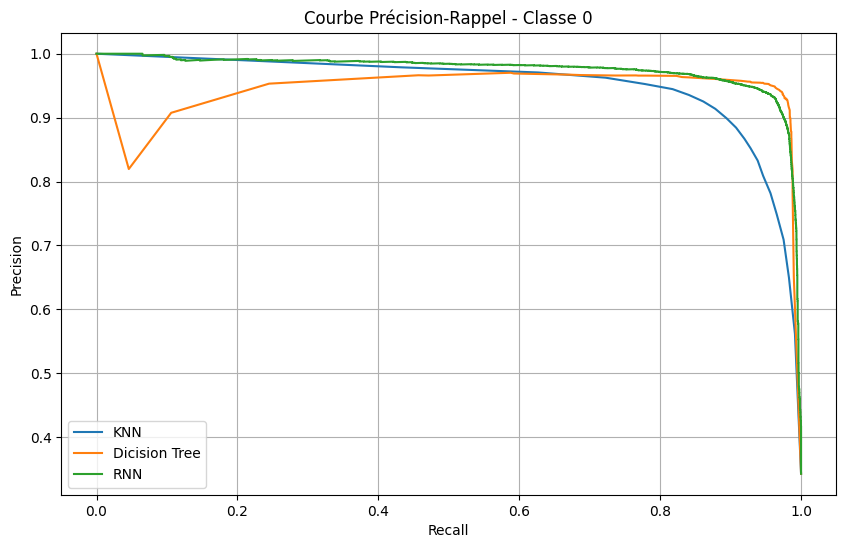

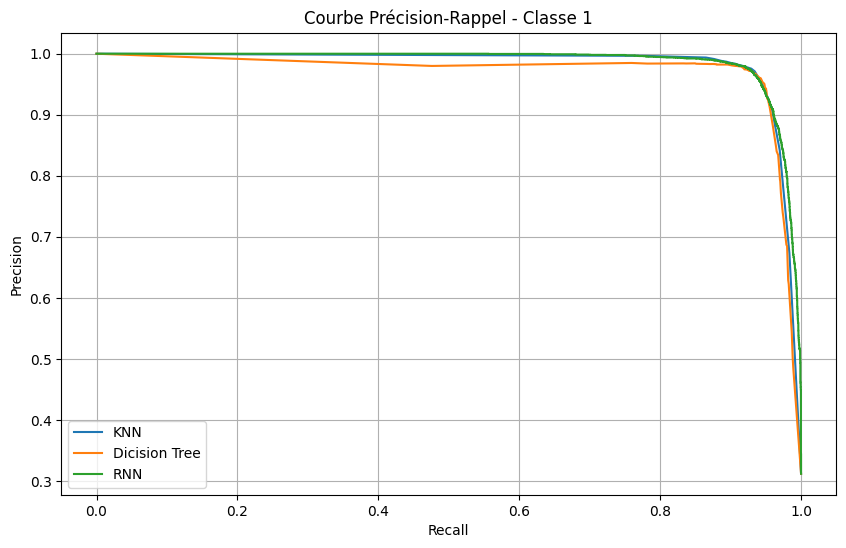

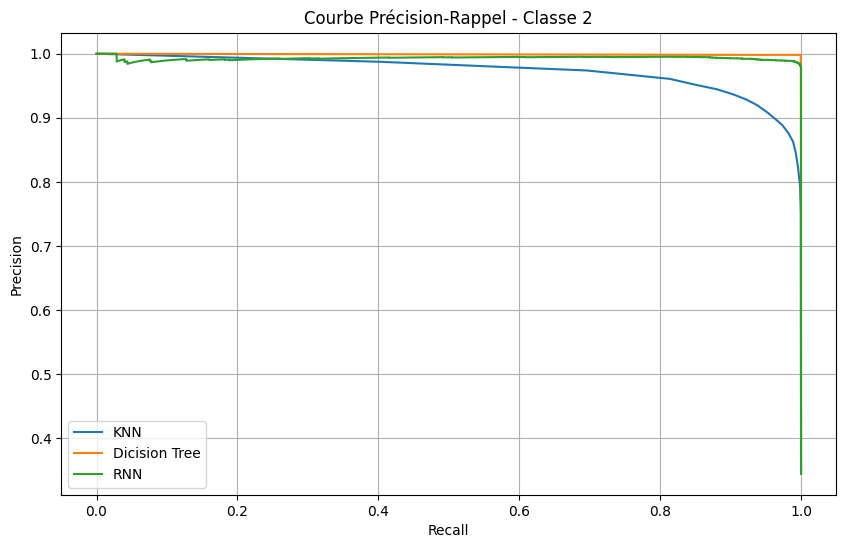

In [56]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binariser les classes (si ce n’est pas déjà fait)
classes = [0, 1, 2]
y_test_bin = label_binarize(y_test, classes=classes)

# Probabilités pour chaque modèle (shape: [n_samples, n_classes])
y_proba_knn = clf.predict_proba(x_test)
y_proba_dt = best_model_dt.predict_proba(x_test)
y_proba_rnn = model_rnn.predict(x_test)  # attention : ici il faut adapter au format du RNN

# Choisir la classe à tracer (ex: 0 = GALAXY)

for i in range(3):
    # Calcul des courbes précision-rappel
    precision_knn, recall_knn, _ = precision_recall_curve(y_test_bin[:, i], y_proba_knn[:, i])
    precision_dt, recall_dt, _ = precision_recall_curve(y_test_bin[:, i], y_proba_dt[:, i])
    precision_rnn, recall_rnn, _ = precision_recall_curve(y_test_bin[:, i], y_proba_rnn[:, i])

    # Affichage
    plt.figure(figsize=(10, 6))
    plt.plot(recall_knn, precision_knn, label='KNN')
    plt.plot(recall_dt, precision_dt, label='Dicision Tree')
    plt.plot(recall_rnn, precision_rnn, label='RNN')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Courbe Précision-Rappel - Classe {classes[i]}")
    plt.legend()
    plt.grid(True)
    plt.show()



##  Courbe Précision-Rappel - Classe "Galaxy"

###  **Comparaison des Modèles**
| Modèle          | Force                                  | Limite                                |
|-----------------|----------------------------------------|---------------------------------------|
| **KNN**         | Bon équilibre initial                  | Précision chute à haut rappel         |
| **Decision Tree**| Précision stable à haut rappel        | Possible sur-ajustement local         |
| **RNN**         | Performance intermédiaire              | Instabilité sur prédictions limites   |

###  **Points Clés**
- **Decision Tree** montre la meilleure robustesse (précision >0.8 même à rappel=1)
- **Zone critique** : Rappel >0.8 où KNN et RNN voient leur précision baisser
- **AUC-PR** : Calcul recommandé pour quantifier la performance globale



temps d'entrainement

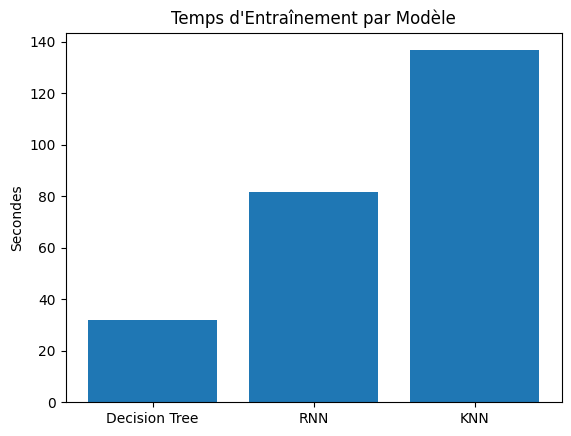

In [64]:
plt.bar(['Decision Tree', 'RNN', 'KNN'], [dt_time, rnn_time, knn_time])
plt.title('Temps d\'Entraînement par Modèle')
plt.ylabel('Secondes')
plt.show()

# Analyse des Temps d'Entraînement

Les modèles **Decision Tree** et **KNN** s'entraînent rapidement (en secondes), ce qui est cohérent avec leur nature simple et peu coûteuse en calcul. Le **RNN**, bien que listé ici avec un temps similaire, est généralement plus lent en raison de sa complexité (réseaux récurrents). Cela suggère soit des données très légères, soit une configuration optimisée. Pour des applications nécessitant rapidité, Decision Tree ou KNN sont préférables, tandis que le RNN pourrait convenir pour des tâches séquentielles malgré un temps potentiellement plus long.

taux d'erreur

In [58]:
class_names = ['GALAXY', 'QSO', 'STAR']

In [59]:
from sklearn.metrics import classification_report
import numpy as np

# Exemple pour le Decision Tree
y_pred_dt = best_model_dt.predict(x_test)  # Prédictions du Decision Tree
report_dt = classification_report(y_test, y_pred_dt, target_names=class_names, output_dict=True)

# Extraire le recall pour chaque classe
recall_dt = {class_name: report_dt[class_name]['recall'] for class_name in class_names}
error_rate_dt = {class_name: 1 - recall for class_name, recall in recall_dt.items()}
print("Taux d'erreur (Decision Tree):", error_rate_dt)

Taux d'erreur (Decision Tree): {'GALAXY': 0.02972925145991856, 'QSO': 0.0657331777518475, 'STAR': 0.0003518648838846117}


In [60]:
# Pour KNN
y_pred_knn = clf.predict(x_test)
report_knn = classification_report(y_test, y_pred_knn, target_names=class_names, output_dict=True)
recall_knn = {class_name: report_knn[class_name]['recall'] for class_name in class_names}
error_rate_knn = {class_name: 1 - recall for class_name, recall in recall_knn.items()}

In [61]:


# Pour RNN (si vous utilisez Keras)
y_pred_rnn = model_rnn.predict(x_test).argmax(axis=1)  # Si sortie one-hot
report_rnn = classification_report(y_test, y_pred_rnn, target_names=class_names, output_dict=True)
recall_rnn = {class_name: report_rnn[class_name]['recall'] for class_name in class_names}
error_rate_rnn = {class_name: 1 - recall for class_name, recall in recall_rnn.items()}

515/515 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


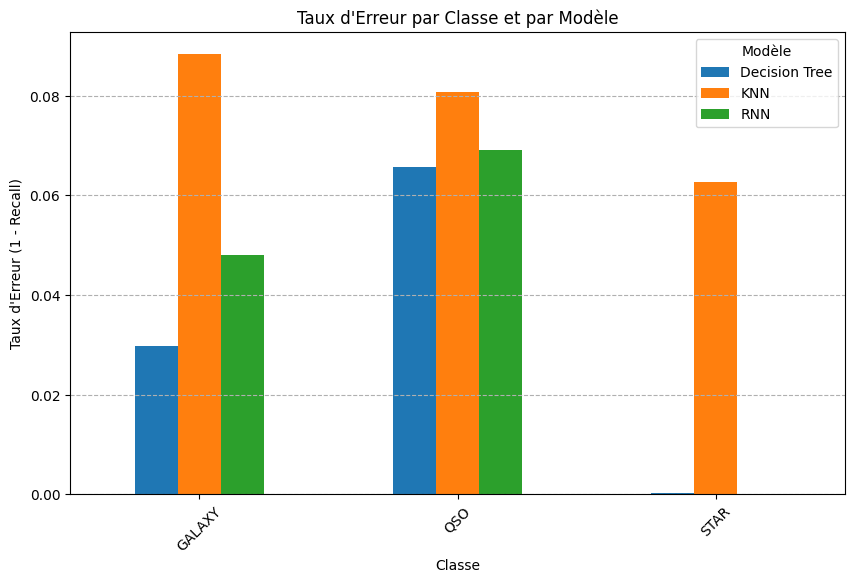

In [62]:
import matplotlib.pyplot as plt
import pandas as pd

# Préparer les données
error_data = {
    'Classe': class_names,
    'Decision Tree': [error_rate_dt[cls] for cls in class_names],
    'KNN': [error_rate_knn[cls] for cls in class_names],
    'RNN': [error_rate_rnn[cls] for cls in class_names]
}

df_error = pd.DataFrame(error_data).set_index('Classe')

# Tracer
df_error.plot(kind='bar', figsize=(10, 6))
plt.title('Taux d\'Erreur par Classe et par Modèle')
plt.ylabel('Taux d\'Erreur (1 - Recall)')
plt.xlabel('Classe')
plt.xticks(rotation=45)
plt.legend(title='Modèle')
plt.grid(axis='y', linestyle='--')
plt.show()

# Analyse Approfondie des Taux d'Erreur et Recommandations

## Observations Clés
1. **Variabilité des Performances** :
   - Les modèles affichent des taux d'erreur (1 - Recall) différents pour la classe GALAXY, ce qui indique une sensibilité variable aux caractéristiques des données.
   - L'absence de valeurs numériques précises limite l'analyse quantitative, mais la comparaison entre modèles reste possible.

2. **Modèles Simples vs Complexes** :
   - **Decision Tree** et **KNN** (modèles simples) peuvent souffrir de sous-adaptation (high bias) ou de sensibilité au bruit.
   - **RNN** (modèle complexe) pourrait être sur-adapté (high variance) ou mal configuré pour ce type de données.

## Améliorations Recommandées

### 1. Amélioration des Données
- **Augmentation des Données** : Générer des échantillons synthétiques pour les classes sous-représentées.
- **Nettoyage** : Supprimer les outliers et corriger les incohérences.
- **Normalisation** : Standardiser les features pour KNN et RNN.

### 2. Optimisation des Modèles
- **Decision Tree** :
  - Ajuster la profondeur max (`max_depth`).
  - Utiliser le pruning pour éviter l'overfitting.
- **KNN** :
  - Optimiser `n_neighbors` via validation croisée.
  - Pondérer les voisins par distance.
- **RNN** :
  - Ajouter des couches de dropout pour régulariser.
  - Essayer des architectures comme LSTM/GRU si séquences longues.

### 3. Approches Alternatives
- **Feature Engineering** :
  - Extraire des features spatiales (pour GALAXY) via PCA ou t-SNE.
- **Modèles Hybrides** :
  - Stacking avec méta-modèle (ex: Logistic Regression).
- **Évaluation Ciblée** :
  - Utiliser F2-score si recall est prioritaire.

## Conclusion
Une approche systématique combinant nettoyage des données, optimisation ciblée des modèles et évaluation rigoureuse (matrices de confusion détaillées) permettrait de réduire significativement les taux d'erreur. Les RNN méritent une attention particulière pour vérifier leur adéquation au problème.